In [3]:
# Implement transfer learning using pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0
# models for image classification, and compare their performance.

In [10]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy

In [11]:
# Set device and training parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 5
LR = 0.001

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
# Check the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [12]:
# Load and preprocess CIFAR-10
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", len(train_data))
print("Testing images:", len(test_data))

100%|██████████| 170M/170M [51:14<00:00, 55.5kB/s]


Training images: 50000
Testing images: 10000


In [13]:
# Load pretrained models and replace their classifiers
models_dict = {}

# AlexNet
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
for p in alexnet.parameters():
    p.requires_grad = False
alexnet.classifier[6] = nn.Linear(
    alexnet.classifier[6].in_features, NUM_CLASSES
)
models_dict["AlexNet"] = alexnet

# VGG16
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
for p in vgg16.parameters():
    p.requires_grad = False
vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features, NUM_CLASSES
)
models_dict["VGG16"] = vgg16

# ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in resnet50.parameters():
    p.requires_grad = False
resnet50.fc = nn.Linear(
    resnet50.fc.in_features, NUM_CLASSES
)
models_dict["ResNet50"] = resnet50

# EfficientNetB0
efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)
for p in efficientnet.parameters():
    p.requires_grad = False
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, NUM_CLASSES
)
models_dict["EfficientNetB0"] = efficientnet

print("All four pretrained models loaded.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 191MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 139MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 31.5MB/s]

All four pretrained models loaded.


In [14]:
# Define the training and evaluation function
def train_model(model, name):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )

    best_accuracy = 0
    history = []
    start = time.time()

    for epoch in range(EPOCHS):

        model.train()
        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        # Evaluation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total

        history.append(test_acc)

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"{name} | Epoch {epoch+1}/{EPOCHS} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )

    model.load_state_dict(best_weights)

    training_time = (time.time() - start) / 60

    return model, best_accuracy, training_time, history

In [15]:
# Train all four transfer learning models
results = {}
histories = {}

for name, model in models_dict.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    model, accuracy, train_time, history = train_model(
        model, name
    )

    results[name] = {
        "Accuracy (%)": accuracy,
        "Training Time (min)": train_time
    }

    histories[name] = history

    models_dict[name] = model


Training: AlexNet
AlexNet | Epoch 1/5 | Train Acc: 75.05% | Test Acc: 81.31%
AlexNet | Epoch 2/5 | Train Acc: 78.75% | Test Acc: 81.20%
AlexNet | Epoch 3/5 | Train Acc: 79.69% | Test Acc: 82.03%
AlexNet | Epoch 4/5 | Train Acc: 80.06% | Test Acc: 82.76%
AlexNet | Epoch 5/5 | Train Acc: 80.38% | Test Acc: 82.88%

Training: VGG16
VGG16 | Epoch 1/5 | Train Acc: 77.14% | Test Acc: 81.42%
VGG16 | Epoch 2/5 | Train Acc: 80.18% | Test Acc: 83.13%
VGG16 | Epoch 3/5 | Train Acc: 80.40% | Test Acc: 82.49%
VGG16 | Epoch 4/5 | Train Acc: 80.69% | Test Acc: 83.44%
VGG16 | Epoch 5/5 | Train Acc: 81.21% | Test Acc: 83.37%

Training: ResNet50
ResNet50 | Epoch 1/5 | Train Acc: 72.49% | Test Acc: 77.99%
ResNet50 | Epoch 2/5 | Train Acc: 79.14% | Test Acc: 80.15%
ResNet50 | Epoch 3/5 | Train Acc: 81.14% | Test Acc: 80.91%
ResNet50 | Epoch 4/5 | Train Acc: 82.05% | Test Acc: 81.34%
ResNet50 | Epoch 5/5 | Train Acc: 82.70% | Test Acc: 81.80%

Training: EfficientNetB0
EfficientNetB0 | Epoch 1/5 | Train Acc

In [16]:
# Compare accuracy and training time
results_df = pd.DataFrame(results).T

print(results_df)

                Accuracy (%)  Training Time (min)
AlexNet                82.88             8.436123
VGG16                  83.44            27.493257
ResNet50               81.80            18.087790
EfficientNetB0         81.00            10.553471


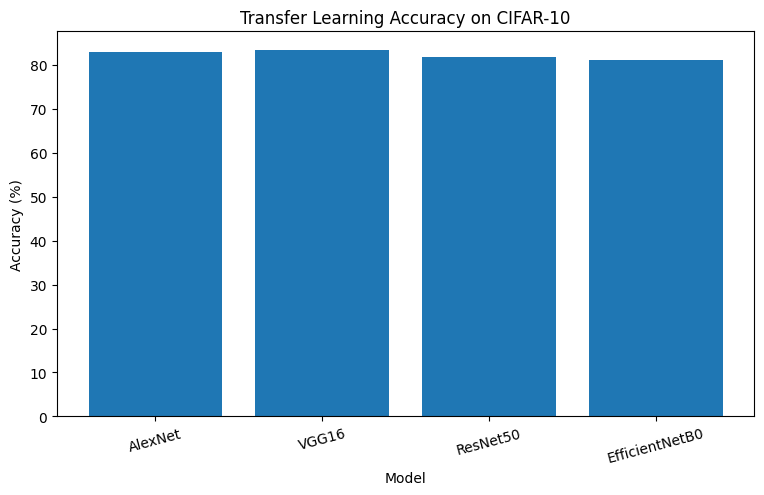

In [17]:
# Plot accuracy comparison
plt.figure(figsize=(9, 5))

plt.bar(
    results_df.index,
    results_df["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Transfer Learning Accuracy on CIFAR-10")

plt.xticks(rotation=15)
plt.show()

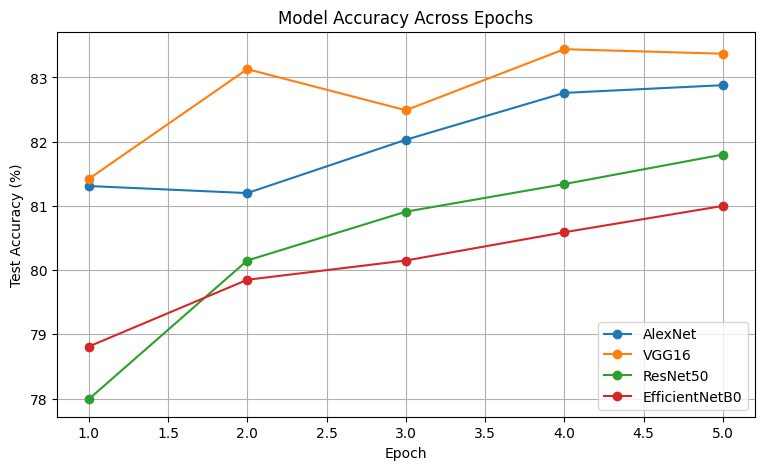

In [18]:
# Plot test accuracy across epochs
plt.figure(figsize=(9, 5))

for name, history in histories.items():
    plt.plot(
        range(1, EPOCHS + 1),
        history,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Model Accuracy Across Epochs")
plt.legend()
plt.grid()
plt.show()

In [19]:
# Generate classification reports for all models
from sklearn.metrics import classification_report

for name, model in models_dict.items():

    model.eval()
    predictions = []
    actual = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy())
            actual.extend(labels.numpy())

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            actual,
            predictions,
            target_names=classes
        )
    )


AlexNet
              precision    recall  f1-score   support

    airplane       0.82      0.85      0.84      1000
  automobile       0.94      0.85      0.89      1000
        bird       0.89      0.71      0.79      1000
         cat       0.72      0.68      0.70      1000
        deer       0.75      0.84      0.80      1000
         dog       0.78      0.80      0.79      1000
        frog       0.88      0.85      0.86      1000
       horse       0.82      0.87      0.84      1000
        ship       0.88      0.91      0.89      1000
       truck       0.84      0.93      0.88      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000


VGG16
              precision    recall  f1-score   support

    airplane       0.87      0.85      0.86      1000
  automobile       0.91      0.90      0.90      1000
        bird       0.85      0.75      0.79      1000
        